In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [ ]:
df=pd.read_csv("netflix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.rename(columns={'listed_in':'genre'},inplace=True)
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genre', 'description'],
      dtype='object')

In [ ]:
# dropin the show id column cuse there is no use of this

In [ ]:
df.drop(columns='show_id',inplace=True)

In [ ]:
df.duplicated().sum()            # dupliacte check krne ke liye

np.int64(0)

In [ ]:
df.isnull().sum()

,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3
genre,0


In [ ]:
df.shape

(8807, 11)

In [ ]:
# subset use krenge kyunki date added wale column mai 10 values hai bs drop na krenge to sare delete ho jayenge

In [ ]:
df.dropna(subset=['date_added'],inplace=True)
df['date_added'].isna().sum()

np.int64(0)

In [ ]:
# dropin the rating null values by subset

In [ ]:
df.dropna(subset=['date_added'],inplace=True)
df['date_added'].isnull().sum()

np.int64(0)

In [ ]:
# duration ki rows ko delete krna hai kyunki they have null values which are 3 only soo its not necessory to be maintained

In [ ]:
df.dropna(subset=['duration'],inplace=True)
df['duration'].isna().sum()

np.int64(0)

In [ ]:
df['date_added']=pd.to_datetime(df['date_added'],errors='coerce')
# coerce isliye kyunki date k format ki vajah se agar date change nhi ho payi to vo null mai convert ho jayegi
df['date_added'].isnull().sum()

np.int64(88)

In [ ]:
df.dropna(subset=['date_added'],inplace=True)
df['date_added'].isna().sum()

np.int64(0)

In [ ]:
# adding day ,month,year name as seperate columns to the dataframe

In [ ]:
df['day']=df['date_added'].dt.day
df['month']=df['date_added'].dt.month
df['year']=df['date_added'].dt.year
df['day_name']=df['date_added'].dt.day_name()
df['month_name']=df['date_added'].dt.month_name()

In [ ]:
df["duration"]=df["duration"].apply(lambda x:int(x.split()[0]))

In [ ]:
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,day_name,month_name
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,Saturday,September
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,Friday,September
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,Friday,September
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021,Friday,September
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,Friday,September


In [ ]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'NR', nan, 'TV-Y7-FV', 'UR'], dtype=object)

In [ ]:
# netflix has officialy categorised theese into 3 main categories

In [ ]:
df['rating'] = df['rating'].replace(['TV-Y','TV-Y7','G','TV-G','PG','TV-PG','TV-Y7-FV'],'Kids')
df['rating'] = df['rating'].replace(['PG-13','TV-14'],'Teens')
df['rating'] = df['rating'].replace(['R','TV-MA','NC-17'],'Adults')
df['rating'] = df['rating'].replace(['NR','UR'],np.nan)
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,day_name,month_name
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,Saturday,September
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,Friday,September
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,Adults,1,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,Friday,September
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,Adults,1,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021,Friday,September
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Adults,2,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,Friday,September


In [ ]:
df['rating'].isna().sum()

np.int64(85)

In [ ]:
df.dropna(subset=['rating'],inplace=True)
df['rating'].isnull().sum()

np.int64(0)

In [ ]:
df[(df["director"].isna())&(df["country"].isna())&(df["cast"].isna())].shape[0]    # teeno ki common row ki null values bata rha hai isme

96

In [ ]:
df.dropna(subset= ["director","country","cast"],how="all",inplace=True)  # how=all isliye lagaya taki sirf common null values udaye vo bs isliye

In [ ]:
df.shape

(8525, 16)

In [ ]:
df.isna().sum()

,0
type,0
title,0
director,2439
cast,704
country,730
date_added,0
release_year,0
rating,0
duration,0
genre,0


In [ ]:
df['cast'][2] # cast kasecond row ka data hai

'Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera'

In [ ]:
df['cast'][2].split(",")

['Sami Bouajila',
 ' Tracy Gotoas',
 ' Samuel Jouy',
 ' Nabiha Akkari',
 ' Sofia Lesaffre',
 ' Salim Kechiouche',
 ' Noureddine Farihi',
 ' Geert Van Rampelberg',
 ' Bakary Diombera']

In [ ]:
df_cast=pd.DataFrame(df['cast'].apply(lambda x: str(x).split(', ')).tolist(),index=df['title'])
df_cast

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
title,,,,,,,,,,,,,,,,,,,,,
Dick Johnson Is Dead,nan,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
Blood & Water,Ama Qamata,Khosi Ngema,Gail Mabalane,Thabang Molaba,Dillon Windvogel,Natasha Thahane,Arno Greeff,Xolile Tshabalala,Getmore Sithole,Cindy Mahlangu,...,None,None,None,None,None,None,None,None,None,None
Ganglands,Sami Bouajila,Tracy Gotoas,Samuel Jouy,Nabiha Akkari,Sofia Lesaffre,Salim Kechiouche,Noureddine Farihi,Geert Van Rampelberg,Bakary Diombera,None,...,None,None,None,None,None,None,None,None,None,None
Kota Factory,Mayur More,Jitendra Kumar,Ranjan Raj,Alam Khan,Ahsaas Channa,Revathi Pillai,Urvi Singh,Arun Kumar,None,None,...,None,None,None,None,None,None,None,None,None,None
Midnight Mass,Kate Siegel,Zach Gilford,Hamish Linklater,Henry Thomas,Kristin Lehman,Samantha Sloyan,Igby Rigney,Rahul Kohli,Annarah Cymone,Annabeth Gish,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zinzana,Ali Suliman,Saleh Bakri,Yasa,Ali Al-Jabri,Mansoor Alfeeli,Ahd,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
Zodiac,Mark Ruffalo,Jake Gyllenhaal,Robert Downey Jr.,Anthony Edwards,Brian Cox,Elias Koteas,Donal Logue,John Carroll Lynch,Dermot Mulroney,Chloë Sevigny,...,None,None,None,None,None,None,None,None,None,None
Zombieland,Jesse Eisenberg,Woody Harrelson,Emma Stone,Abigail Breslin,Amber Heard,Bill Murray,Derek Graf,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [ ]:
# stack se list ko reverse krke list bana deta hai
df_cast=pd.DataFrame(df['cast'].apply(lambda x: str(x).split(', ')).tolist(),index=df['title'])
df_cast=df_cast.stack()
df_cast

title                  
Dick Johnson Is Dead  0                      nan
Blood & Water         0               Ama Qamata
                      1              Khosi Ngema
                      2            Gail Mabalane
                      3           Thabang Molaba
                                   ...          
Zubaan                3         Manish Chaudhary
                      4             Meghna Malik
                      5            Malkeet Rauni
                      6           Anita Shabdish
                      7    Chittaranjan Tripathy
Length: 63644, dtype: object

In [ ]:
df_cast=pd.DataFrame(df_cast)
df_cast

0
title                                        
Dick Johnson Is Dead 0                    nan
Blood & Water        0             Ama Qamata
                     1            Khosi Ngema
                     2          Gail Mabalane
                     3         Thabang Molaba
...                                       ...
Zubaan               3       Manish Chaudhary
                     4           Meghna Malik
                     5          Malkeet Rauni
                     6         Anita Shabdish
                     7  Chittaranjan Tripathy

[63644 rows x 1 columns]

In [ ]:
df_cast.reset_index(inplace=True)
df_cast

,title,level_1,0
0,Dick Johnson Is Dead,0,nan
1,Blood & Water,0,Ama Qamata
2,Blood & Water,1,Khosi Ngema
3,Blood & Water,2,Gail Mabalane
4,Blood & Water,3,Thabang Molaba
...,...,...,...
63639,Zubaan,3,Manish Chaudhary
63640,Zubaan,4,Meghna Malik
63641,Zubaan,5,Malkeet Rauni
63642,Zubaan,6,Anita Shabdish


In [ ]:
df_cast=df_cast[['title',0]]
df_cast

,title,0
0,Dick Johnson Is Dead,nan
1,Blood & Water,Ama Qamata
2,Blood & Water,Khosi Ngema
3,Blood & Water,Gail Mabalane
4,Blood & Water,Thabang Molaba
...,...,...
63639,Zubaan,Manish Chaudhary
63640,Zubaan,Meghna Malik
63641,Zubaan,Malkeet Rauni
63642,Zubaan,Anita Shabdish


In [ ]:
df_cast.columns=['title','cast']
df_cast

,title,cast
0,Dick Johnson Is Dead,nan
1,Blood & Water,Ama Qamata
2,Blood & Water,Khosi Ngema
3,Blood & Water,Gail Mabalane
4,Blood & Water,Thabang Molaba
...,...,...
63639,Zubaan,Manish Chaudhary
63640,Zubaan,Meghna Malik
63641,Zubaan,Malkeet Rauni
63642,Zubaan,Anita Shabdish


In [ ]:
df_cast.replace('nan',np.nan,inplace=True)
df_cast.isna().sum()

/tmp/ipython-input-154984155.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cast.replace('nan',np.nan,inplace=True)


,0
title,0
cast,704


In [ ]:
df_genre=pd.DataFrame(df['genre'].apply(lambda x: str(x).split(', ')).tolist(),index=df['title'])  # index ko title dedia
df_genre=df_genre.stack()
df_genre=pd.DataFrame(df_genre)
df_genre.reset_index(inplace=True)
df_genre=df_genre[['title',0]]
df_genre.columns=['title','genre']
df_genre.replace('nan',np.nan,inplace=True)
df_genre.isna().sum()

,0
title,0
genre,0


In [ ]:
df_director=pd.DataFrame(df['director'].apply(lambda x: str(x).split(', ')).tolist(),index=df['title'])
df_director=df_director.stack()
df_director=pd.DataFrame(df_director)
df_director.reset_index(inplace=True)
df_director=df_director[['title',0]]
df_director.columns=['title','director']
df_director.replace('nan',np.nan,inplace=True)
df_director.isna().sum()

,0
title,0
director,2439


In [ ]:
df_country=pd.DataFrame(df['country'].apply(lambda x: str(x).split(', ')).tolist(),index=df['title'])
df_country=df_country.stack()
df_country=pd.DataFrame(df_country)
df_country.reset_index(inplace=True)
df_country=df_country[['title',0]]
df_country.columns=['title','country']
df_country.replace('nan',np.nan,inplace=True)
df_country.isna().sum()

,0
title,0
country,730


In [ ]:
df12=df_cast.merge(df_genre, on='title')   # do ko ek sath merge krne ke liye .merge ka use hota hai
df12

,title,cast,genre
0,Dick Johnson Is Dead,NaN,Documentaries
1,Blood & Water,Ama Qamata,International TV Shows
2,Blood & Water,Ama Qamata,TV Dramas
3,Blood & Water,Ama Qamata,TV Mysteries
4,Blood & Water,Khosi Ngema,International TV Shows
...,...,...,...
146662,Zubaan,Anita Shabdish,International Movies
146663,Zubaan,Anita Shabdish,Music & Musicals
146664,Zubaan,Chittaranjan Tripathy,Dramas
146665,Zubaan,Chittaranjan Tripathy,International Movies


In [ ]:
df123=df_director.merge(df12, on= 'title')
df123

,title,director,cast,genre
0,Dick Johnson Is Dead,Kirsten Johnson,NaN,Documentaries
1,Blood & Water,NaN,Ama Qamata,International TV Shows
2,Blood & Water,NaN,Ama Qamata,TV Dramas
3,Blood & Water,NaN,Ama Qamata,TV Mysteries
4,Blood & Water,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...
158309,Zubaan,Mozez Singh,Anita Shabdish,International Movies
158310,Zubaan,Mozez Singh,Anita Shabdish,Music & Musicals
158311,Zubaan,Mozez Singh,Chittaranjan Tripathy,Dramas
158312,Zubaan,Mozez Singh,Chittaranjan Tripathy,International Movies


In [ ]:
df1234=df_country.merge(df123, on='title')
df1234

,title,country,director,cast,genre
0,Dick Johnson Is Dead,United States,Kirsten Johnson,NaN,Documentaries
1,Blood & Water,South Africa,NaN,Ama Qamata,International TV Shows
2,Blood & Water,South Africa,NaN,Ama Qamata,TV Dramas
3,Blood & Water,South Africa,NaN,Ama Qamata,TV Mysteries
4,Blood & Water,South Africa,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...,...
198399,Zubaan,India,Mozez Singh,Anita Shabdish,International Movies
198400,Zubaan,India,Mozez Singh,Anita Shabdish,Music & Musicals
198401,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,Dramas
198402,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,International Movies


In [ ]:
df_new=df.merge(df1234, on='title')
df_new

,type,title,director_x,cast_x,country_x,date_added,release_year,rating,duration,genre_x,description,day,month,year,day_name,month_name,country_y,director_y,cast_y,genre_y
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,Saturday,September,United States,Kirsten Johnson,NaN,Documentaries
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,Friday,September,South Africa,NaN,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,Friday,September,South Africa,NaN,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,Friday,September,South Africa,NaN,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,Friday,September,South Africa,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198399,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,Saturday,March,India,Mozez Singh,Anita Shabdish,International Movies
198400,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,Saturday,March,India,Mozez Singh,Anita Shabdish,Music & Musicals
198401,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,Saturday,March,India,Mozez Singh,Chittaranjan Tripathy,Dramas
198402,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,Saturday,March,India,Mozez Singh,Chittaranjan Tripathy,International Movies


In [ ]:
df_new.drop(columns=['cast_x','director_x','country_x','genre_x'],inplace=True)
df_new.rename(columns={'country_y':'country','director_y':'director','cast_y':'cast','genre_y':'genre'},inplace=True)

In [ ]:
# do column ban gaye x wala hai bina clean wala yani messed up data
# y wala hai clean data jo  hamne banaya tha pichle codes se
# isliye  x walo ko remove kra hai fir y walo ko real column banaya hai

In [ ]:
df_new.head()

,type,title,date_added,release_year,rating,duration,description,day,month,year,day_name,month_name,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,Saturday,September,United States,Kirsten Johnson,NaN,Documentaries
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,Friday,September,South Africa,NaN,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,Friday,September,South Africa,NaN,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,Friday,September,South Africa,NaN,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,Friday,September,South Africa,NaN,Khosi Ngema,International TV Shows


In [ ]:
df_new['cast']=df_new['cast'].replace(np.nan,'unknown')   # = lag rha hai isliye inplace true nhi likha jata hai
df_new['country']=df_new['country'].replace(np.nan,'unknwon')
df_new['director']=df_new['director'].replace(np.nan,'unknown')

In [ ]:
df_new.head()

,type,title,date_added,release_year,rating,duration,description,day,month,year,day_name,month_name,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,Saturday,September,United States,Kirsten Johnson,unknown,Documentaries
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,Friday,September,South Africa,unknown,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,Friday,September,South Africa,unknown,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,Friday,September,South Africa,unknown,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,Friday,September,South Africa,unknown,Khosi Ngema,International TV Shows


In [ ]:
df_new.duplicated().sum()

np.int64(55)

In [ ]:
# in the new data frame there are 55 duplicatwd values so delete them and keep only one ek to ktkhni hi pdegi na


In [ ]:
df_new.drop_duplicates(keep='first',inplace=True)
df_new.shape

(198349, 16)

In [ ]:
# creating two more data for bettr analysis

In [ ]:
df_movies=df_new.loc[df_new['type']=='Movie']    # bina .loc lagaye bhi aajayega same code se hi
df_tvs=df_new.loc[df_new['type']=='TV Show']

In [ ]:
df_movies.shape

(144240, 16)

In [ ]:
df_tvs.shape

(54109, 16)

In [ ]:
df_tvs.rename(columns={'duration':'seasons'},inplace=True)   # tv show mai duration 1,2,3 krke thori dikha sakta hai isliye duration ko season krke dikha dete hai

/tmp/ipython-input-1555993408.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tvs.rename(columns={'duration':'seasons'},inplace=True)   # tv show mai duration 1,2,3 krke thori dikha sakta hai isliye duration ko season krke dikha dete hai


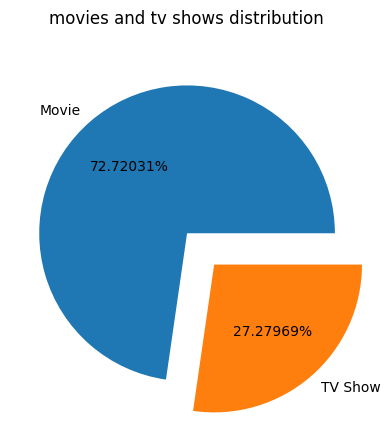

In [ ]:
plt.pie(df_new['type'].value_counts(),labels=df_new['type'].value_counts().index,explode=(0.08,0.2),autopct='%0.5f%%')
plt.suptitle("movies and tv shows distribution")
plt.show()

In [ ]:
df_temp=df_new.drop_duplicates(subset=['country','title'])         # jab 2 column ko nikalo to usme bahot suplicates aati hai isliye unhe hatana pdega
x=df_temp['country'].value_counts().head(10)

In [ ]:
x

,count
country,
United States,3596
India,1038
United Kingdom,772
unknwon,730
Canada,427
France,383
Japan,313
Spain,228
Germany,223


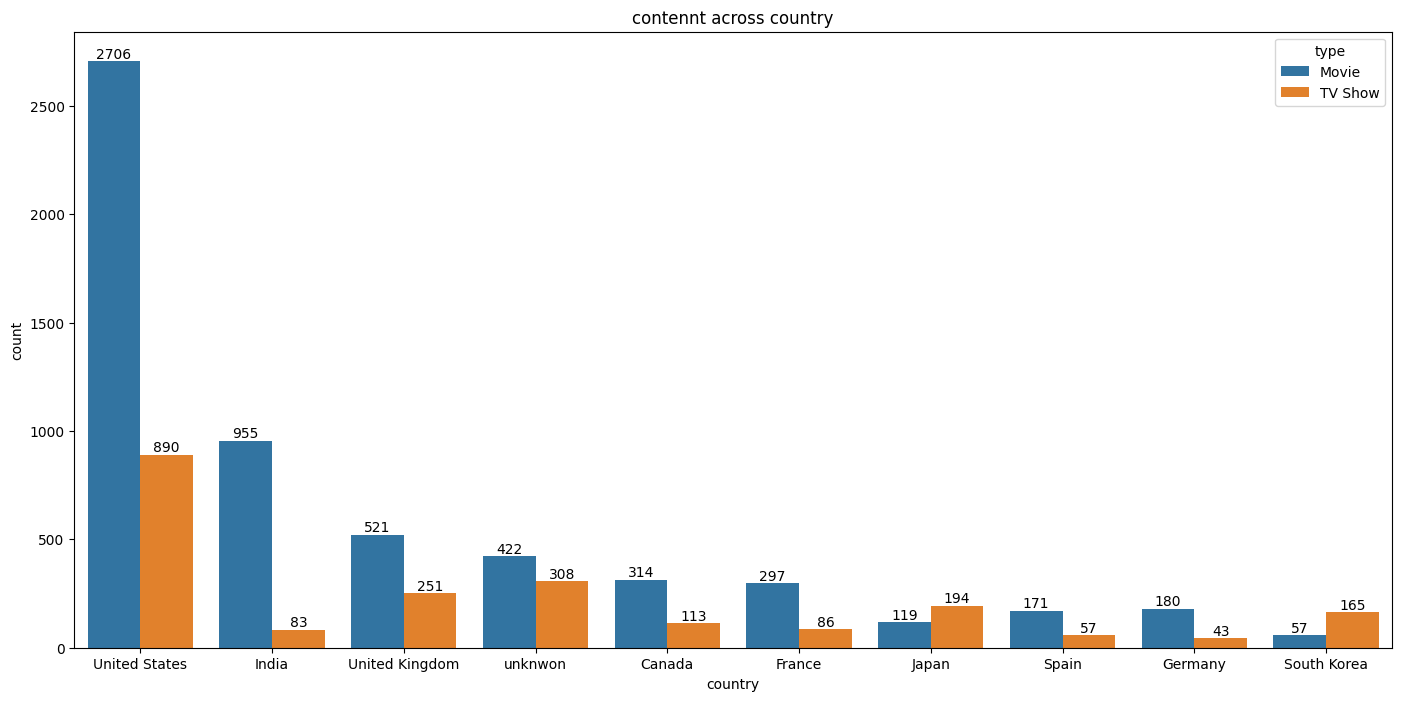

In [ ]:
plt.figure(figsize=(17,8))
plt.title("contennt across country")
label=sns.countplot(data=df_temp,x='country',hue='type',order=x.index)  # x se index ban jayenge yani country ke index
for i in label.containers:
  label.bar_label(i)   # counting ko bar pr dikhana hai to ye wala code lagega
plt.show()

/tmp/ipython-input-626898185.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x='director',order=df_movies_temp['director'].value_counts()[1:11].index,palette='husl')
/tmp/ipython-input-626898185.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x='director',order=df_tvs_temp['director'].value_counts()[1:11].index,palette='husl')


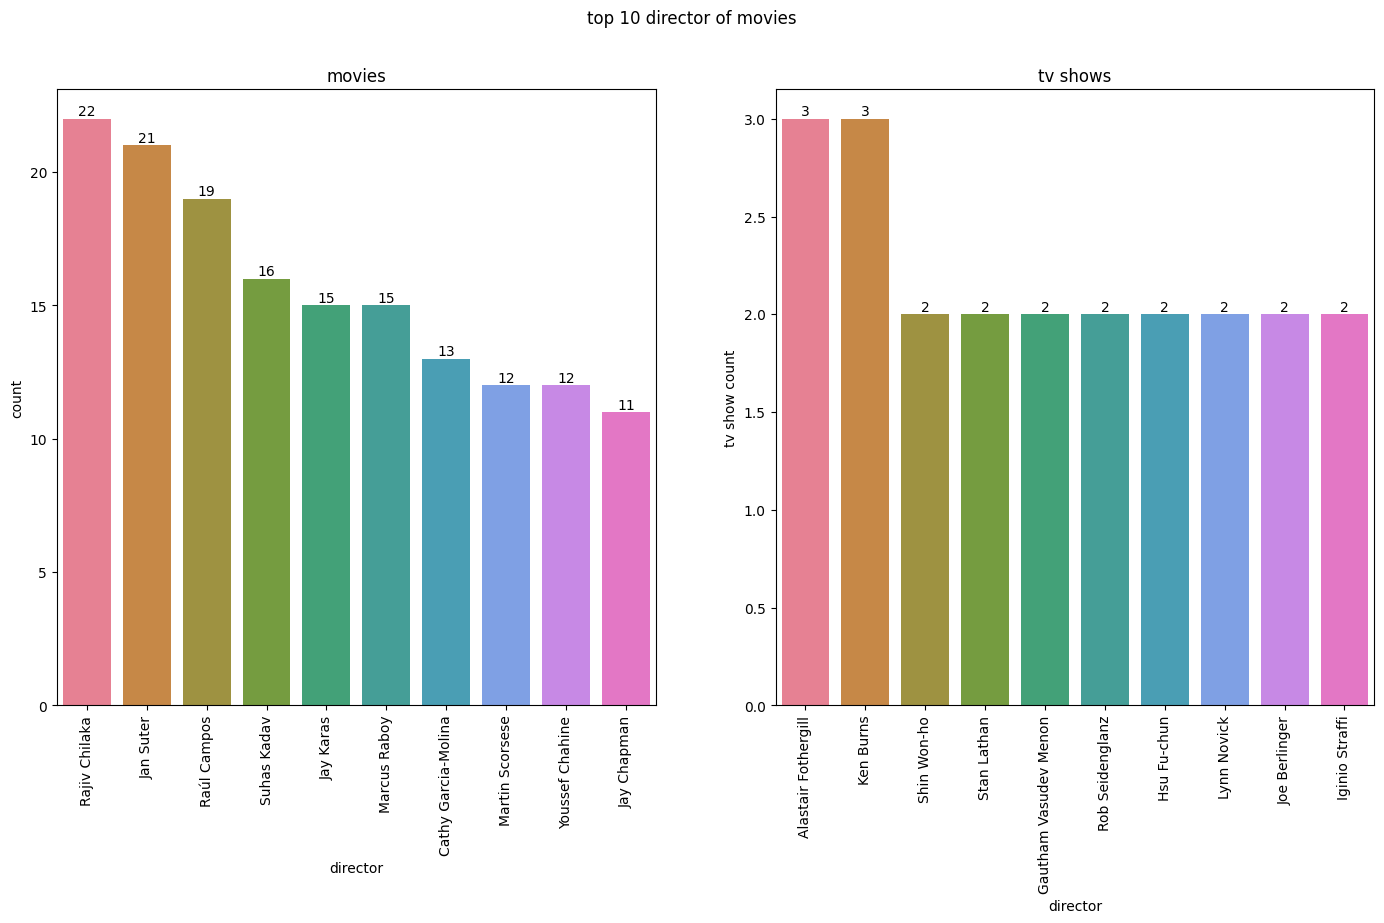

In [ ]:
df_movies_temp=df_movies.drop_duplicates(subset=['director','title'])
df_tvs_temp=df_tvs.drop_duplicates(subset=['director','title'])
plt.figure(figsize=(17,8))
plt.suptitle("top 10 director of movies ")
plt.subplot(1,2,1)  # ye position hai graph ke liye
label=sns.countplot(data=df_movies_temp,x='director',order=df_movies_temp['director'].value_counts()[1:11].index,palette='husl')
for i in label.containers:
  label.bar_label(i)
plt.title("movies")
plt.xticks(rotation=90)
plt.xlabel("director")
plt.ylabel("count")


plt.subplot(1,2,2)
label=sns.countplot(data=df_tvs_temp,x='director',order=df_tvs_temp['director'].value_counts()[1:11].index,palette='husl')
for i in label.containers:

  label.bar_label(i)
plt.title("tv shows")
plt.xticks(rotation=90)
plt.xlabel("director")
plt.ylabel("tv show count")
plt.show()

/tmp/ipython-input-953663261.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x='genre',order=df_movies_temp['genre'].value_counts()[1:11].index,palette='husl')
/tmp/ipython-input-953663261.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x='genre',order=df_tvs_temp['genre'].value_counts()[1:11].index,palette='husl')


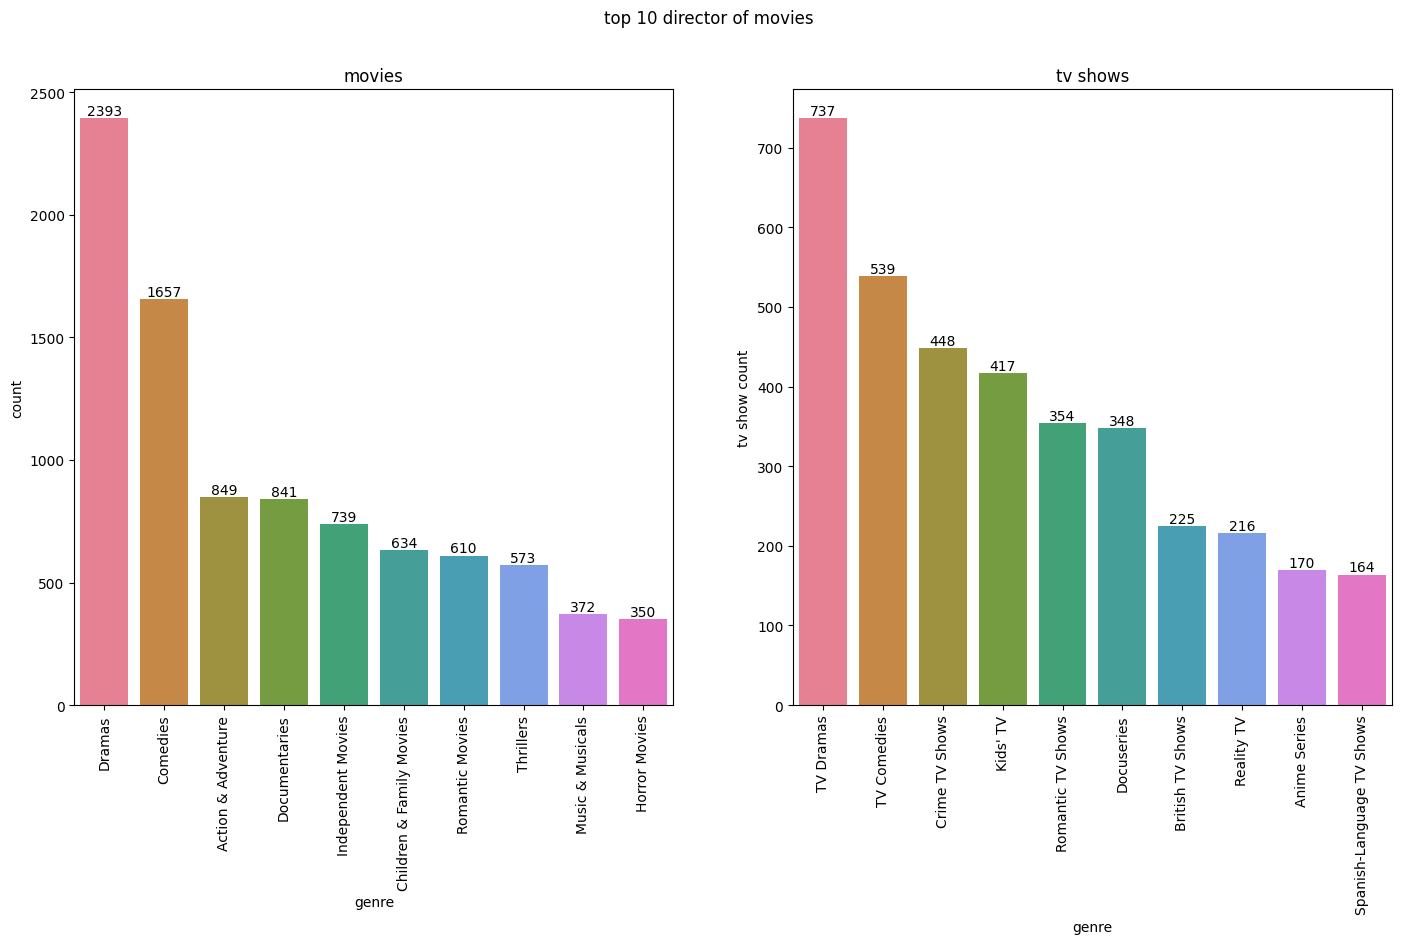

In [ ]:
df_movies_temp=df_movies.drop_duplicates(subset=['genre','title'])
df_tvs_temp=df_tvs.drop_duplicates(subset=['genre','title'])
plt.figure(figsize=(17,8))
plt.suptitle("top 10 director of movies ")
plt.subplot(1,2,1)  # ye position hai graph ke liye
label=sns.countplot(data=df_movies_temp,x='genre',order=df_movies_temp['genre'].value_counts()[1:11].index,palette='husl')
for i in label.containers:
  label.bar_label(i)
plt.title("movies")
plt.xticks(rotation=90)
plt.xlabel("genre")
plt.ylabel("count")


plt.subplot(1,2,2)
label=sns.countplot(data=df_tvs_temp,x='genre',order=df_tvs_temp['genre'].value_counts()[1:11].index,palette='husl')
for i in label.containers:

  label.bar_label(i)
plt.title("tv shows")
plt.xticks(rotation=90)
plt.xlabel("genre")
plt.ylabel("tv show count")
plt.show()

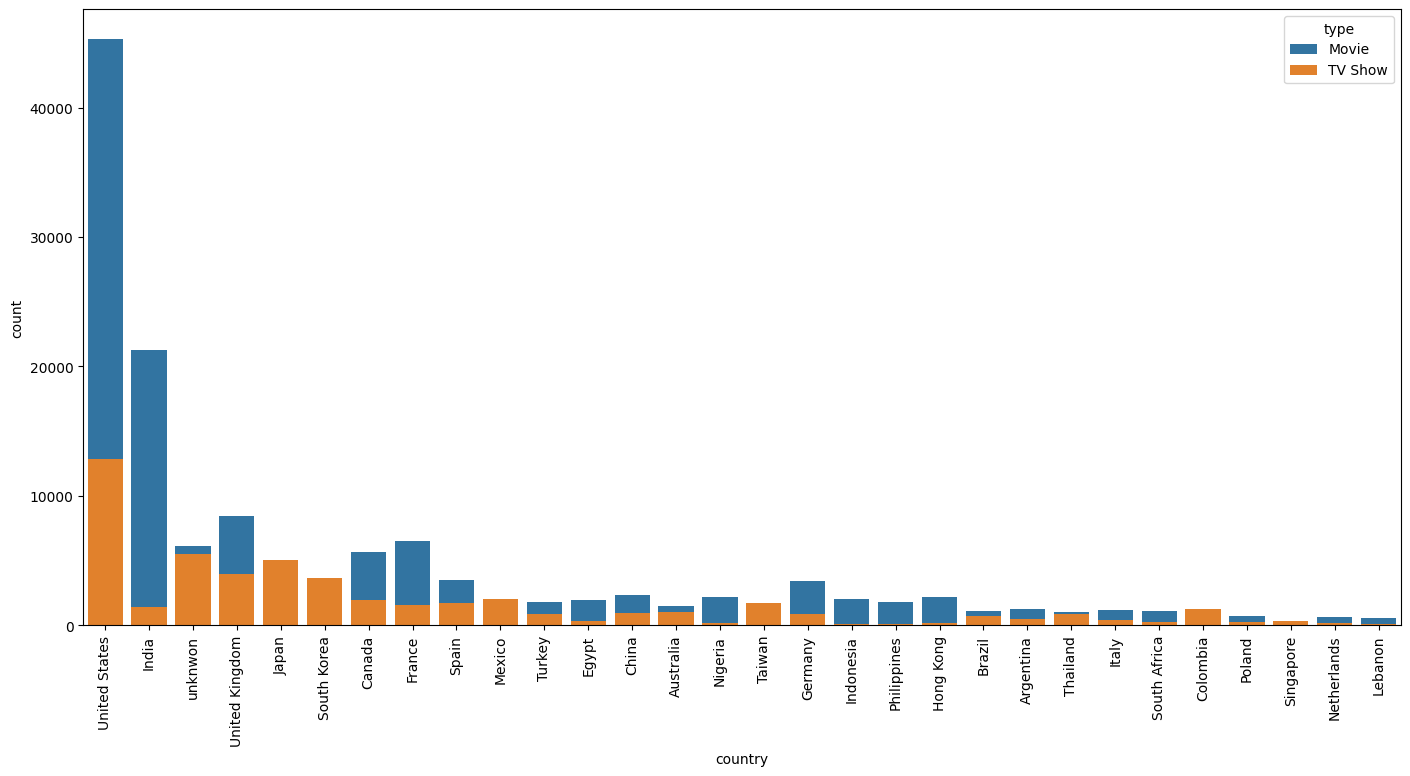

In [ ]:
df_temp=df_new.drop_duplicates(subset=['genre','title'])
plt.figure(figsize=(17,8))             # dodge =false krme se ek ke uper ek ban jata hai
plt.xticks(rotation=90)
sns.countplot(data=df_new,x='country',order=df_temp['country'].value_counts().head(30).index,dodge=False,hue='type')
plt.show()


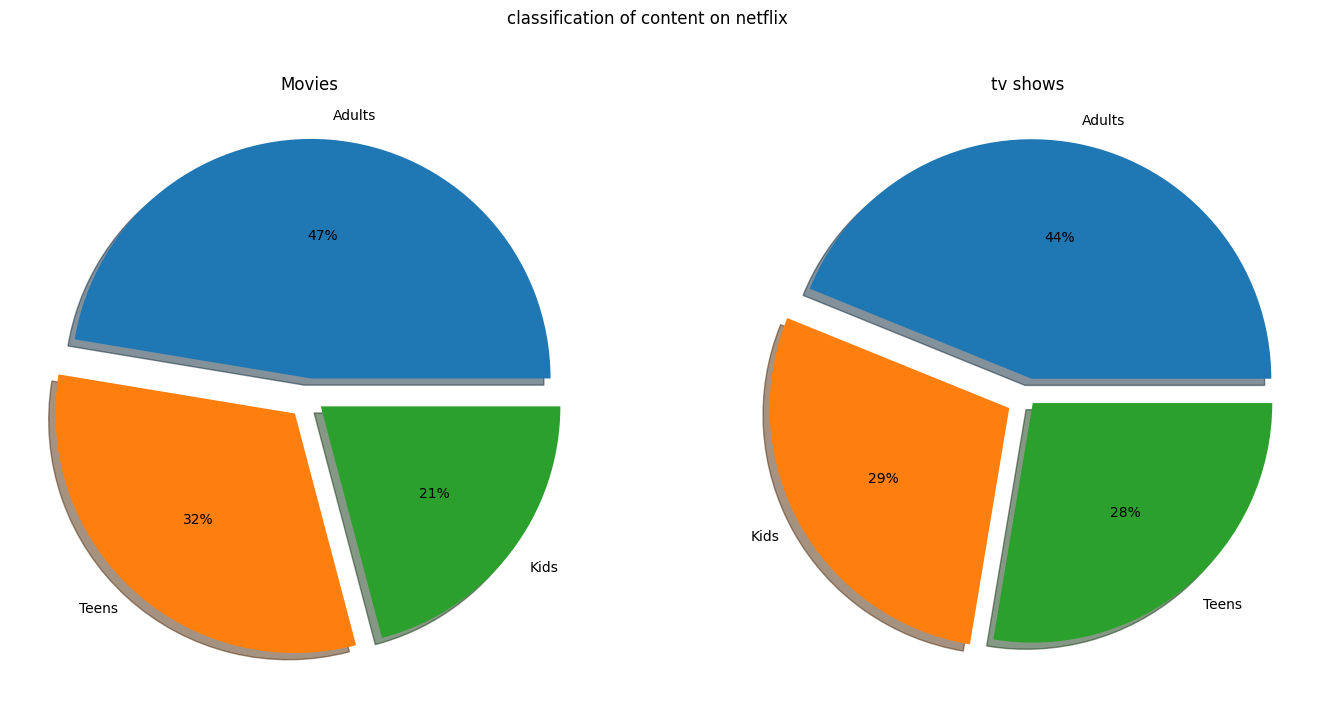

In [ ]:
df_movies_temp=df_movies.drop_duplicates(subset=['rating','title'])
df_tvs_temp=df_tvs.drop_duplicates(subset=['rating','title'])
plt.figure(figsize=(17,8))
plt.suptitle('classification of content on netflix')
plt.subplot(1,2,1)
plt.pie(df_movies_temp['rating'].value_counts(),labels=df_movies_temp['rating'].value_counts().index,autopct='%0.0f%%',explode=(0.08,0.09,0.06),shadow=True)
plt.title('Movies')

plt.subplot(1,2,2)
plt.pie(df_tvs_temp['rating'].value_counts(),labels=df_tvs_temp['rating'].value_counts().index,autopct='%0.0f%%',explode=(0.08,0.09,0.03),shadow=True)
plt.title("tv shows")
plt.show()

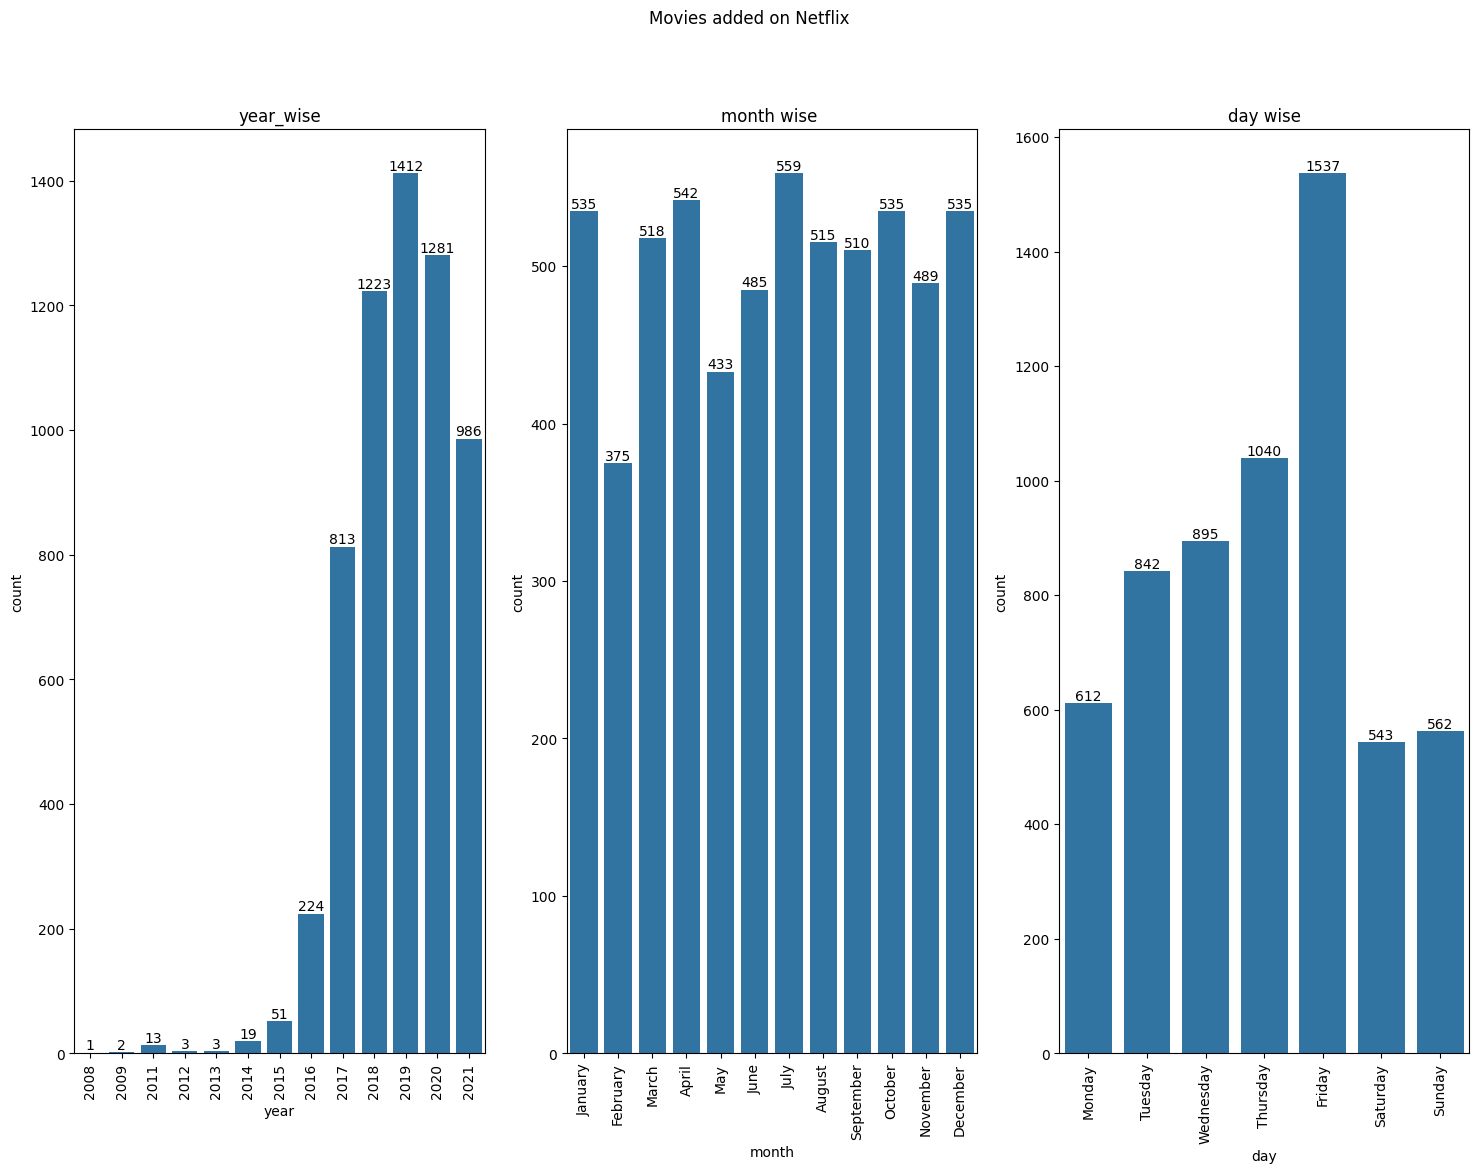

In [ ]:
df_movies_temp=df_movies.drop_duplicates(subset=['year','title'])
mv_year=df_movies_temp['year'].value_counts()
mv_year.sort_index(inplace=True)
   # year ka to sort ho jayega aaram se


month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
mv_month=df_movies_temp['month_name'].value_counts().loc[month_order]
 # month ka shi sequence mai data nhi aa payega isliye use month ka order bana kr dedia aur use .loc krdia ki us hisab se dikha

days_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
mv_day=df_movies_temp['day_name'].value_counts().loc[days_order]  # same goes for days

plt.figure(figsize=(18,12))
plt.suptitle("Movies added on Netflix")
plt.subplot(1,3,1)
label=sns.countplot(data=df_movies_temp,x='year',order=mv_year.index)
for i in label.containers:
  label.bar_label(i)

plt.xticks(rotation=90)
plt.xlabel("year")
plt.ylabel("count")
plt.title("year_wise")


plt.subplot(1,3,2)
label=sns.countplot(data=df_movies_temp,x='month_name',order=mv_month.index)
for i in label.containers:
  label.bar_label(i)
plt.xticks(rotation=90)
plt.xlabel("month")
plt.ylabel("count")
plt.title("month wise ")


plt.subplot(1,3,3)
label=sns.countplot(data=df_movies_temp,x='day_name',order=mv_day.index)
for i in label.containers:
  label.bar_label(i)
plt.xticks(rotation=90)
plt.xlabel("day")
plt.ylabel("count")      # color lane hai to palette laga do
plt.title("day wise")



plt.show()

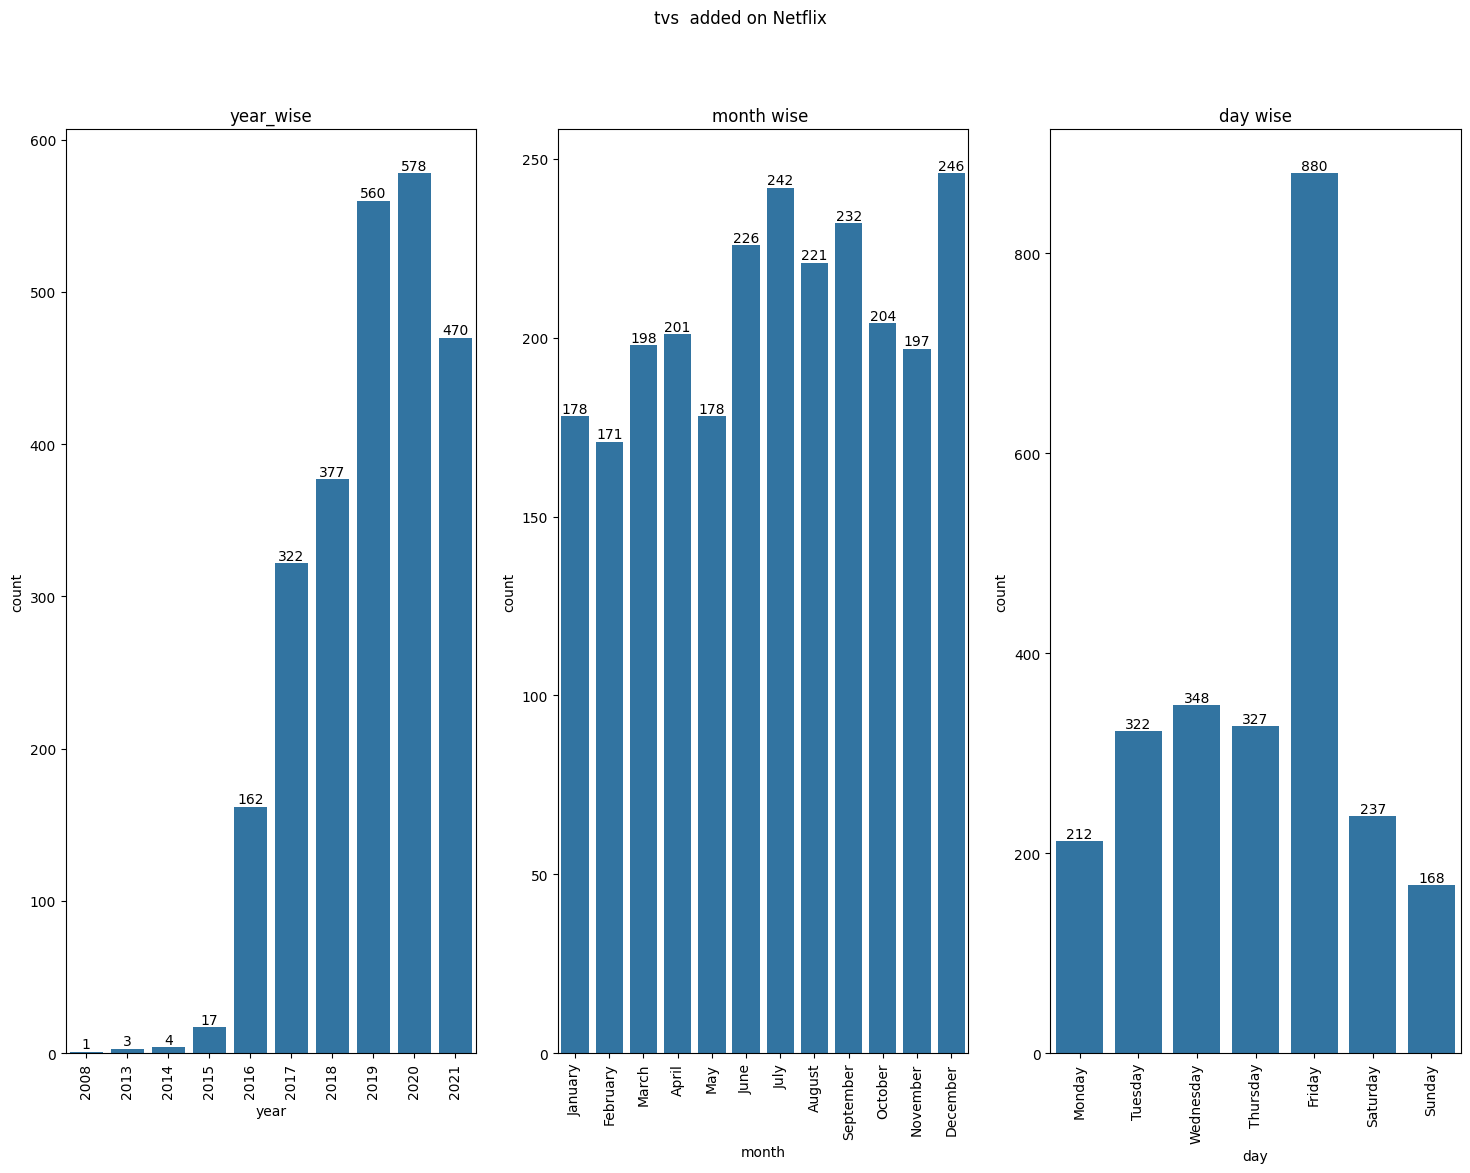

In [ ]:
df_tvs_temp=df_tvs.drop_duplicates(subset=['year','title'])
mv_year=df_tvs_temp['year'].value_counts()
mv_year.sort_index(inplace=True)
   # year ka to sort ho jayega aaram se


month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
mv_month=df_movies_temp['month_name'].value_counts().loc[month_order]
 # month ka shi sequence mai data nhi aa payega isliye use month ka order bana kr dedia aur use .loc krdia ki us hisab se dikha

days_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
mv_day=df_movies_temp['day_name'].value_counts().loc[days_order]  # same goes for days

plt.figure(figsize=(18,12))
plt.suptitle("tvs  added on Netflix")
plt.subplot(1,3,1)
label=sns.countplot(data=df_tvs_temp,x='year',order=mv_year.index)
for i in label.containers:
  label.bar_label(i)

plt.xticks(rotation=90)
plt.xlabel("year")
plt.ylabel("count")
plt.title("year_wise")


plt.subplot(1,3,2)
label=sns.countplot(data=df_tvs_temp,x='month_name',order=mv_month.index)
for i in label.containers:
  label.bar_label(i)
plt.xticks(rotation=90)
plt.xlabel("month")
plt.ylabel("count")
plt.title("month wise ")


plt.subplot(1,3,3)
label=sns.countplot(data=df_tvs_temp,x='day_name',order=mv_day.index)
for i in label.containers:
  label.bar_label(i)
plt.xticks(rotation=90)
plt.xlabel("day")
plt.ylabel("count")      # color lane hai to palette laga do
plt.title("day wise")



plt.show()

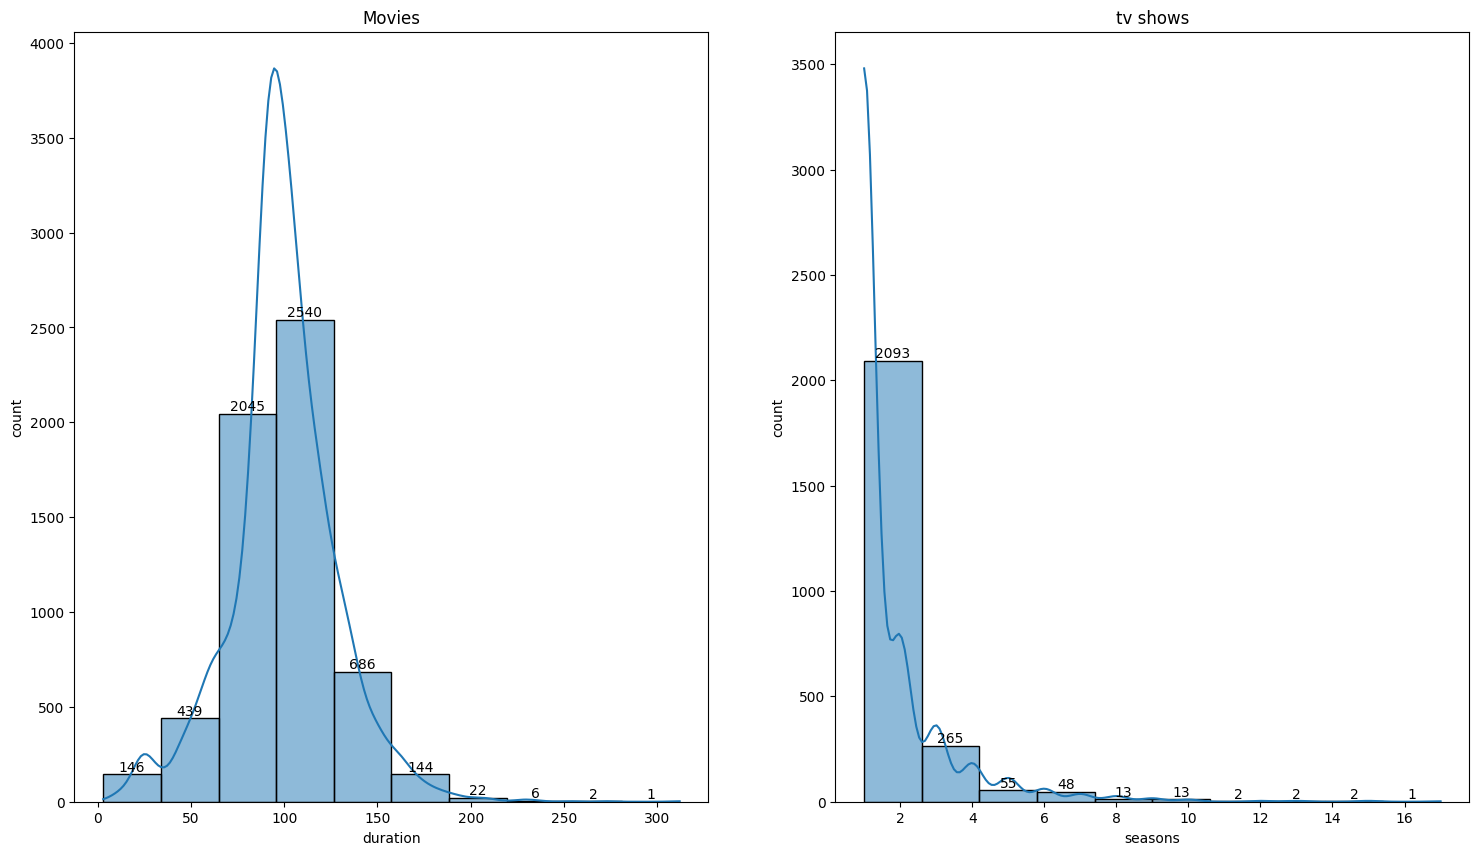

In [ ]:
df_movies_temp=df_movies.drop_duplicates(subset=['duration','title'])
df_tvs_temp=df_tvs_temp.drop_duplicates(subset=['seasons','title'])   # kyunki tv  show mai seasons ko  change kia hi nhi

plt.figure(figsize=(18,10))
plt.subplot(1,2,1)
label=sns.histplot(df_movies_temp['duration'].astype(int),bins=10,kde=True)   # bins matlab class intervals
for i in label.containers:
  label.bar_label(i)
plt.xlabel('duration')
plt.ylabel('count')
plt.title('Movies')


plt.subplot(1,2,2)
label=sns.histplot(df_tvs_temp['seasons'].astype(int),bins=10,kde=True)
for i in label.containers:
  label.bar_label(i)
plt.xlabel('seasons')
plt.ylabel('count')
plt.title('tv shows')
plt.show()